# Uncertainty Propagation Paradox Analysis

**Pipeline 1** (EXFOR→samples→MF34): ~2% propagated uncertainty  
**Pipeline 2** (MF34→perturbation factors): ~8% propagated uncertainty

Pipeline 1's MF34 has *bigger* diagonal uncertainties, yet 4× smaller propagated uncertainty. This notebook diagnoses why.

In [1]:
# Cell 0 — Config & imports
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import eval_legendre

sys.path.insert(0, "/home/MONLEON-JUAN/kika")
from kika.endf.read_endf import read_endf

# File paths
P1_PARQUET = "/share_snc/snc/JuanMonleon/ENDF_samples/cap3/legendre_coefficients_all_samples.parquet"
P2_PARQUET = "/share_snc/snc/JuanMonleon/ENDF_samples/endf_perturbation_factors_20260302_152032.parquet"
ENDF_FILE  = "/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/26-Fe-56g.txt"

# Energy range of interest (MeV)
E_MIN, E_MAX = 0.845, 4.1
# L-orders present in data
L_ORDERS = [1, 2, 3, 4, 5, 6]
# Near-zero threshold for relative quantities
ABS_THRESHOLD = 0.001

# Matplotlib style
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print("Config loaded.")

Config loaded.


In [2]:
# Cell 1 — Load data

# --- Pipeline 1: EXFOR MC samples ---
p1_df = pd.read_parquet(P1_PARQUET)
p1_nominal = p1_df[p1_df["sample_idx"] == 0].sort_values("energy_mev").reset_index(drop=True)
p1_samples = p1_df[p1_df["sample_idx"] > 0].copy()

p1_energies = p1_nominal["energy_mev"].values  # MeV
n_p1_energies = len(p1_energies)
n_p1_samples = p1_samples["sample_idx"].nunique()
coeff_cols = [f"a_{l}" for l in L_ORDERS]

# Pivot samples into (n_samples, n_energies, n_L) array
p1_arr = np.zeros((n_p1_samples, n_p1_energies, len(L_ORDERS)))
for i, sidx in enumerate(sorted(p1_samples["sample_idx"].unique())):
    s = p1_samples[p1_samples["sample_idx"] == sidx].sort_values("energy_mev")
    p1_arr[i] = s[coeff_cols].values

p1_nominal_arr = p1_nominal[coeff_cols].values  # (n_energies, n_L) — EXFOR nominal

print(f"Pipeline 1: {n_p1_samples} MC samples, {n_p1_energies} energies, {len(L_ORDERS)} L-orders")
print(f"  Energy range: {p1_energies.min():.4f} – {p1_energies.max():.4f} MeV")

# --- Pipeline 2: MF34 perturbation factors ---
p2_df = pd.read_parquet(P2_PARQUET)
p2_factor_cols = [c for c in p2_df.columns if c != "Sample_ID"]

# Parse column names into (L, E_low, E_high)
p2_meta = []
for c in p2_factor_cols:
    m = re.match(r"Fe56_MT2_L(\d+)_(.+)_(.+)", c)
    p2_meta.append({"col": c, "L": int(m.group(1)),
                     "E_low": float(m.group(2)), "E_high": float(m.group(3))})
p2_meta = pd.DataFrame(p2_meta)
p2_meta["E_mid"] = (p2_meta["E_low"] + p2_meta["E_high"]) / 2  # eV
p2_meta["E_mid_mev"] = p2_meta["E_mid"] / 1e6

p2_factors = p2_df[p2_factor_cols].values  # (n_samples, n_factor_cols)
n_p2_samples = len(p2_df)

print(f"\nPipeline 2: {n_p2_samples} samples, {len(p2_factor_cols)} factor columns")
print(f"  L-orders: {sorted(p2_meta['L'].unique())}")
print(f"  Energy range: {p2_meta['E_low'].min()/1e6:.4f} – {p2_meta['E_high'].max()/1e6:.4f} MeV")

# --- ENDF nominal ---
endf = read_endf(ENDF_FILE, mf_numbers=4)
mf4 = endf[4]  # access via __getitem__
mt2 = mf4.sections[2]
endf_energies_ev = np.array(mt2.legendre_energies)
endf_coeffs_raw = mt2.legendre_coefficients  # list of lists (a1, a2, ...), no a0

# Filter to EXFOR energy range and zero-pad to 6 orders
mask_endf = (endf_energies_ev / 1e6 >= E_MIN) & (endf_energies_ev / 1e6 <= E_MAX)
endf_e_mev = endf_energies_ev[mask_endf] / 1e6
endf_coeffs = np.zeros((mask_endf.sum(), len(L_ORDERS)))
for i, idx in enumerate(np.where(mask_endf)[0]):
    c = endf_coeffs_raw[idx]
    n = min(len(c), len(L_ORDERS))
    endf_coeffs[i, :n] = c[:n]

print(f"\nENDF nominal: {len(endf_e_mev)} energies in [{E_MIN}, {E_MAX}] MeV")
print(f"  Max L-order in file: {max(len(c) for c in endf_coeffs_raw)}")

Pipeline 1: 100 MC samples, 1693 energies, 6 L-orders
  Energy range: 0.8470 – 4.0000 MeV



Pipeline 2: 512 samples, 648 factor columns
  L-orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  Energy range: 0.8468 – 4.0750 MeV



ENDF nominal: 1721 energies in [0.845, 4.1] MeV
  Max L-order in file: 32


In [3]:
# Cell 2 — Compute Pipeline 1 effective perturbation factors
# For each MC sample, compute factor = a_l(sample) / a_l(ENDF_nominal)
# using nearest-neighbor energy matching from P1 energies to ENDF energies

# Match P1 energies to nearest ENDF energies
from scipy.interpolate import interp1d

# Interpolate ENDF nominal coefficients onto P1 energy grid
endf_on_p1 = np.zeros((n_p1_energies, len(L_ORDERS)))
for j in range(len(L_ORDERS)):
    f_interp = interp1d(endf_e_mev, endf_coeffs[:, j], kind="nearest",
                        bounds_error=False, fill_value="extrapolate")
    endf_on_p1[:, j] = f_interp(p1_energies)

# Pipeline 1 factors relative to ENDF nominal
# p1_arr: (n_samples, n_energies, n_L), endf_on_p1: (n_energies, n_L)
p1_factors_vs_endf = np.full_like(p1_arr, np.nan)
for j in range(len(L_ORDERS)):
    denom = endf_on_p1[:, j]
    valid = np.abs(denom) > ABS_THRESHOLD
    for i in range(n_p1_samples):
        p1_factors_vs_endf[i, valid, j] = p1_arr[i, valid, j] / denom[valid]

# Pipeline 1 factors relative to EXFOR nominal (sample_idx=0)
p1_factors_vs_exfor = np.full_like(p1_arr, np.nan)
for j in range(len(L_ORDERS)):
    denom = p1_nominal_arr[:, j]
    valid = np.abs(denom) > ABS_THRESHOLD
    for i in range(n_p1_samples):
        p1_factors_vs_exfor[i, valid, j] = p1_arr[i, valid, j] / denom[valid]

# Average P1 factors into Pipeline 2's multigroup bins for direct comparison
p2_bins_by_L = {}
for L in L_ORDERS:
    l_idx = L - 1  # index into L_ORDERS
    meta_L = p2_meta[p2_meta["L"] == L].reset_index(drop=True)
    n_bins = len(meta_L)
    p1_binned = np.full((n_p1_samples, n_bins), np.nan)
    for b in range(n_bins):
        e_lo = meta_L.iloc[b]["E_low"] / 1e6
        e_hi = meta_L.iloc[b]["E_high"] / 1e6
        mask = (p1_energies >= e_lo) & (p1_energies < e_hi)
        if mask.sum() > 0:
            for i in range(n_p1_samples):
                vals = p1_factors_vs_endf[i, mask, l_idx]
                good = ~np.isnan(vals)
                if good.sum() > 0:
                    p1_binned[i, b] = np.nanmean(vals)
    p2_bins_by_L[L] = {"meta": meta_L, "p1_binned": p1_binned}

print("Pipeline 1 effective factors computed.")
print(f"  vs ENDF: non-NaN fraction = {np.mean(~np.isnan(p1_factors_vs_endf)):.1%}")
print(f"  vs EXFOR: non-NaN fraction = {np.mean(~np.isnan(p1_factors_vs_exfor)):.1%}")

Pipeline 1 effective factors computed.
  vs ENDF: non-NaN fraction = 97.6%
  vs EXFOR: non-NaN fraction = 64.0%


Perturbation factor std(factor) — relative to ENDF nominal


/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=dd

,P1 median std(factor),P1 mean std(factor),P1 max std(factor),P2 median std(factor),P2 mean std(factor),P2 max std(factor)
L,,,,,,
1,0.1345,0.5534,9.1834,0.1792,0.1551,0.2907
2,0.0577,0.0593,0.1377,0.0903,0.0750,0.1395
3,0.1046,0.3552,3.4834,0.0611,0.0515,0.0949
4,0.1485,0.3764,1.8950,0.0353,0.0319,0.0626
5,0.3563,0.4161,1.3511,0.0280,0.0235,0.0478
6,0.1302,0.3643,5.4530,0.0064,0.0099,0.0360


/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=dd

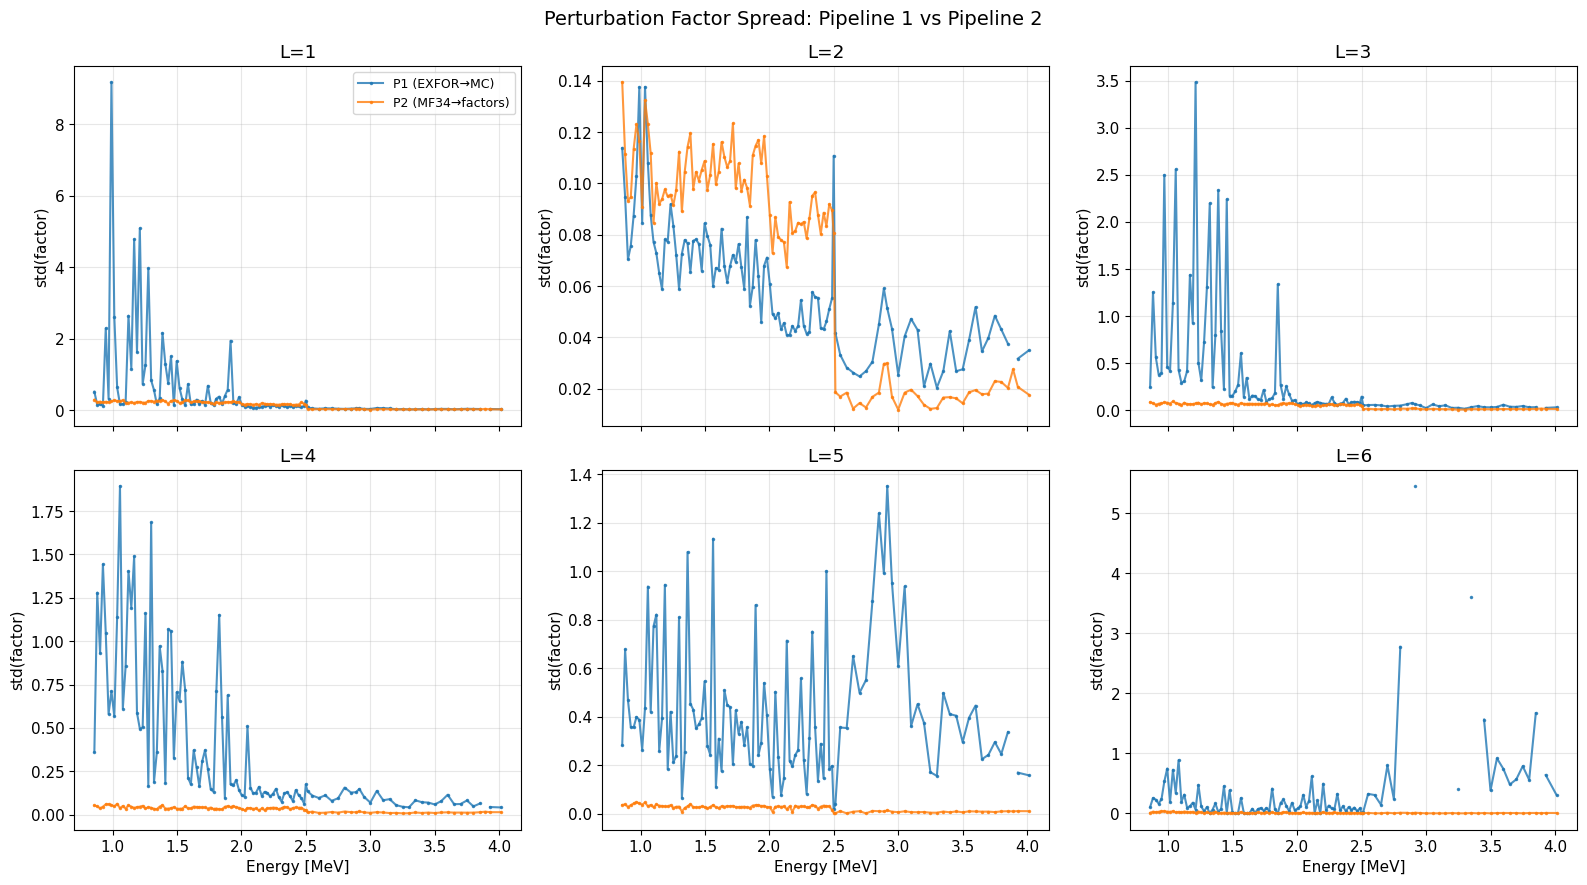

In [4]:
# Cell 3 — Compare perturbation factor distributions

# Per-L summary: std of factors for both pipelines (multigroup-binned)
rows = []
for L in L_ORDERS:
    l_idx = L - 1
    meta_L = p2_bins_by_L[L]["meta"]
    p1_binned = p2_bins_by_L[L]["p1_binned"]  # (n_p1_samples, n_bins)

    # Pipeline 2 factors for this L
    p2_cols_L = meta_L["col"].values
    p2_vals = p2_df[p2_cols_L].values  # (n_p2_samples, n_bins)

    p1_std = np.nanstd(p1_binned, axis=0)  # std across samples per bin
    p2_std = np.std(p2_vals, axis=0)

    rows.append({
        "L": L,
        "P1 median std(factor)": np.nanmedian(p1_std),
        "P1 mean std(factor)": np.nanmean(p1_std),
        "P1 max std(factor)": np.nanmax(p1_std),
        "P2 median std(factor)": np.median(p2_std),
        "P2 mean std(factor)": np.mean(p2_std),
        "P2 max std(factor)": np.max(p2_std),
    })

summary_df = pd.DataFrame(rows).set_index("L")
print("Perturbation factor std(factor) — relative to ENDF nominal")
print("=" * 80)
display(summary_df.round(4))

# --- Plot: std(factor) vs energy for each L ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
for idx, L in enumerate(L_ORDERS):
    ax = axes.flat[idx]
    meta_L = p2_bins_by_L[L]["meta"]
    p1_binned = p2_bins_by_L[L]["p1_binned"]
    p2_cols_L = meta_L["col"].values
    p2_vals = p2_df[p2_cols_L].values

    e_mid = meta_L["E_mid_mev"].values
    p1_std = np.nanstd(p1_binned, axis=0)
    p2_std = np.std(p2_vals, axis=0)

    ax.plot(e_mid, p1_std, ".-", label="P1 (EXFOR→MC)", alpha=0.8, markersize=3)
    ax.plot(e_mid, p2_std, ".-", label="P2 (MF34→factors)", alpha=0.8, markersize=3)
    ax.set_title(f"L={L}")
    ax.set_ylabel("std(factor)")
    if idx >= 3:
        ax.set_xlabel("Energy [MeV]")
    if idx == 0:
        ax.legend(fontsize=9)

fig.suptitle("Perturbation Factor Spread: Pipeline 1 vs Pipeline 2", fontsize=14)
plt.tight_layout()
plt.show()

Absolute perturbation std(Δa_l)


/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=dd

,P1 median std(Δa),P1 mean std(Δa),P2 median std(Δa),P2 mean std(Δa),Ratio P2/P1 median
L,,,,,
1,0.039950,0.036278,0.050447,0.046581,1.262734
2,0.017408,0.017199,0.023267,0.021929,1.336544
3,0.011494,0.011633,0.004734,0.005581,0.411909
4,0.005744,0.006178,0.001139,0.001295,0.198366
5,0.003452,0.004001,0.000286,0.000443,0.082993
6,0.001035,0.001562,0.000040,0.000091,0.038560


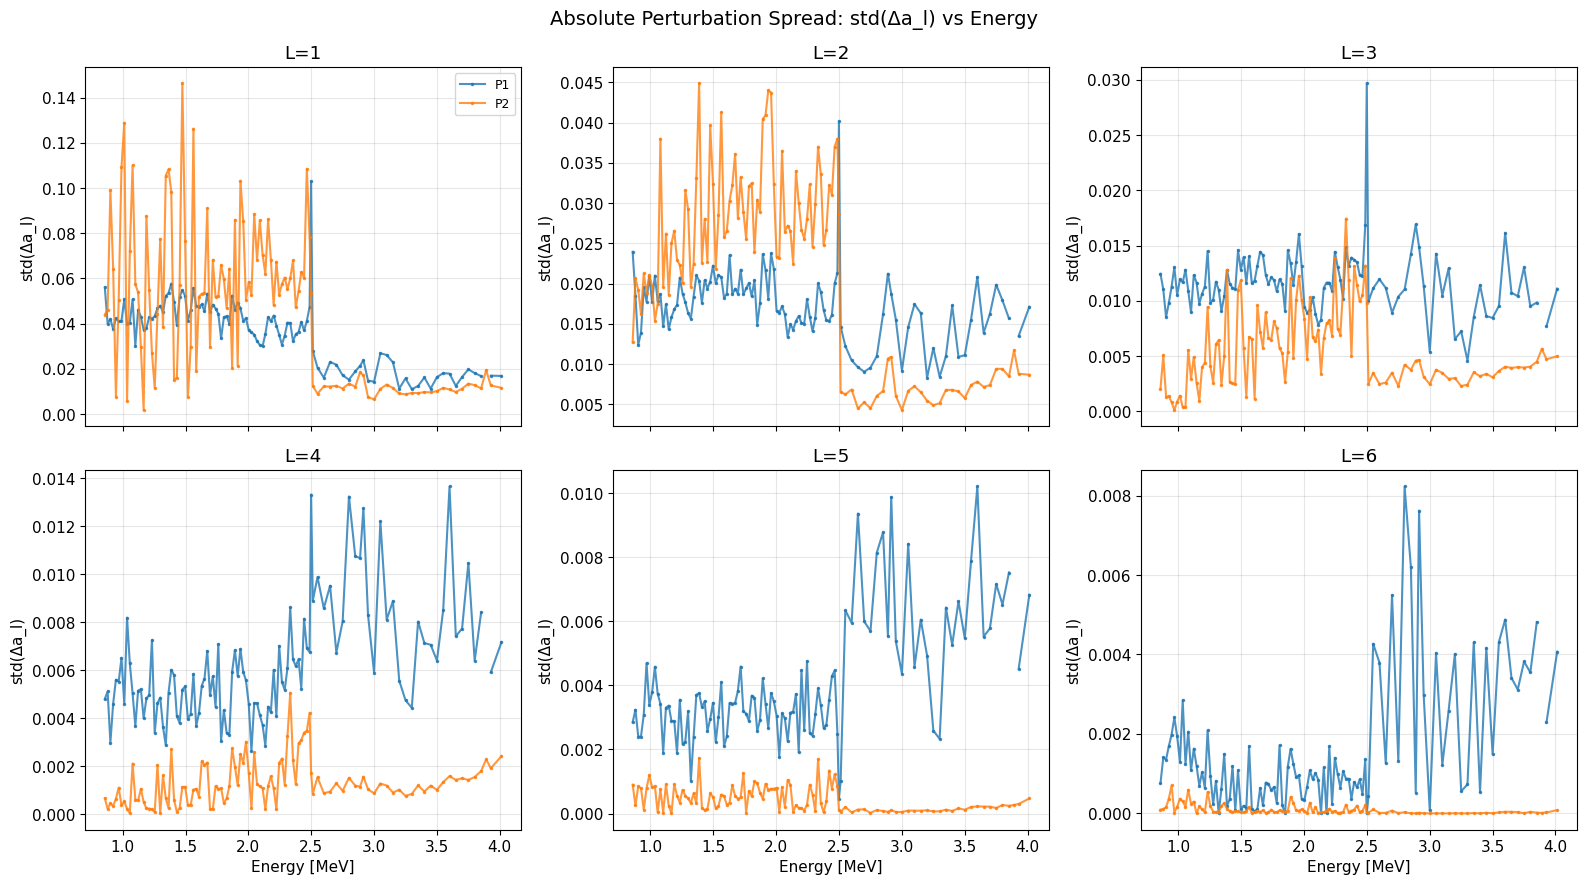

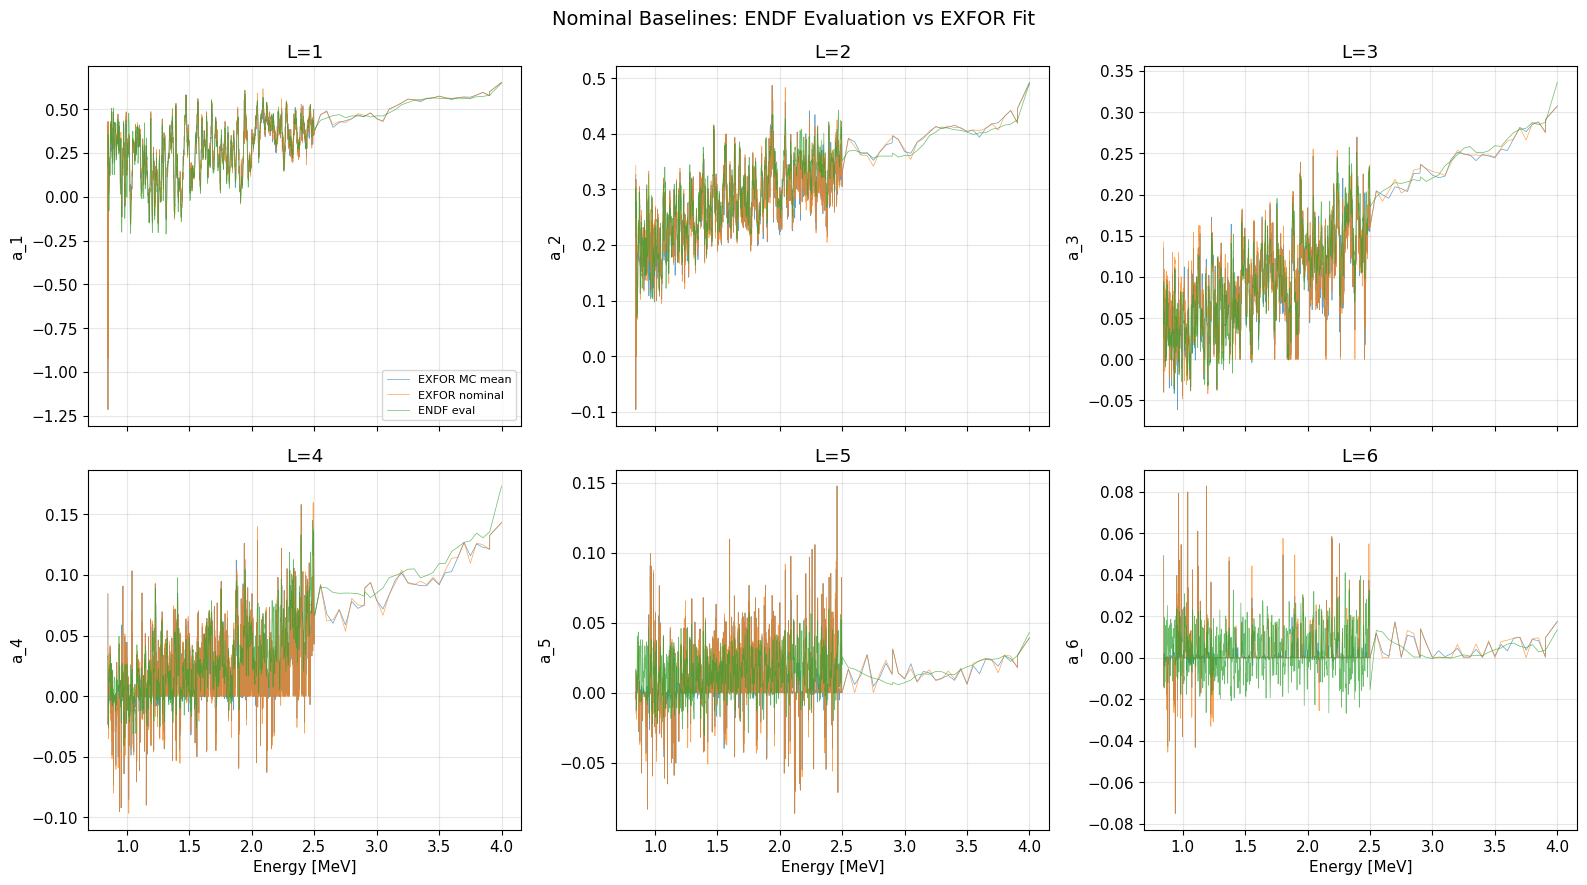

In [5]:
# Cell 4 — Compare absolute perturbations (KEY ANALYSIS)

# Pipeline 1: Δa_l = a_l(sample) - a_l(ENDF_nominal)
p1_delta = p1_arr - endf_on_p1[np.newaxis, :, :]  # (n_samples, n_energies, n_L)

# Pipeline 2: Δa_l = a_l(ENDF) * (factor - 1), computed per multigroup bin
# We need ENDF nominal averaged into P2 bins
rows_abs = []
fig1, axes1 = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9), sharex=True)

for idx, L in enumerate(L_ORDERS):
    l_idx = L - 1
    meta_L = p2_bins_by_L[L]["meta"]
    p2_cols_L = meta_L["col"].values
    p2_vals = p2_df[p2_cols_L].values  # (n_p2_samples, n_bins)
    e_mid = meta_L["E_mid_mev"].values

    # ENDF nominal in P2 bins (nearest-neighbor from endf_e_mev)
    f_endf = interp1d(endf_e_mev, endf_coeffs[:, l_idx], kind="nearest",
                      bounds_error=False, fill_value="extrapolate")
    endf_in_bins = f_endf(e_mid)

    # P2 absolute perturbation
    p2_delta = endf_in_bins[np.newaxis, :] * (p2_vals - 1.0)  # (n_samples, n_bins)
    p2_delta_std = np.std(p2_delta, axis=0)

    # P1 absolute perturbation averaged into bins
    p1_delta_binned = np.full((n_p1_samples, len(meta_L)), np.nan)
    for b in range(len(meta_L)):
        e_lo = meta_L.iloc[b]["E_low"] / 1e6
        e_hi = meta_L.iloc[b]["E_high"] / 1e6
        mask = (p1_energies >= e_lo) & (p1_energies < e_hi)
        if mask.sum() > 0:
            p1_delta_binned[:, b] = np.mean(p1_delta[:, mask, l_idx], axis=1)

    p1_delta_std = np.nanstd(p1_delta_binned, axis=0)

    rows_abs.append({
        "L": L,
        "P1 median std(Δa)": np.nanmedian(p1_delta_std),
        "P1 mean std(Δa)": np.nanmean(p1_delta_std),
        "P2 median std(Δa)": np.median(p2_delta_std),
        "P2 mean std(Δa)": np.mean(p2_delta_std),
        "Ratio P2/P1 median": np.median(p2_delta_std) / np.nanmedian(p1_delta_std) if np.nanmedian(p1_delta_std) > 0 else np.nan,
    })

    # Plot absolute perturbation std
    ax = axes1.flat[idx]
    ax.plot(e_mid, p1_delta_std, ".-", label="P1", alpha=0.8, markersize=3)
    ax.plot(e_mid, p2_delta_std, ".-", label="P2", alpha=0.8, markersize=3)
    ax.set_title(f"L={L}")
    ax.set_ylabel("std(Δa_l)")
    if idx >= 3:
        ax.set_xlabel("Energy [MeV]")
    if idx == 0:
        ax.legend(fontsize=9)

    # Plot baseline comparison: ENDF vs EXFOR mean
    ax2 = axes2.flat[idx]
    p1_mean = np.mean(p1_arr[:, :, l_idx], axis=0)  # mean across MC samples
    ax2.plot(p1_energies, p1_mean, "-", label="EXFOR MC mean", alpha=0.7, linewidth=0.5)
    ax2.plot(p1_energies, p1_nominal_arr[:, l_idx], "-", label="EXFOR nominal", alpha=0.7, linewidth=0.5)
    ax2.plot(endf_e_mev, endf_coeffs[:, l_idx], "-", label="ENDF eval", alpha=0.7, linewidth=0.5)
    ax2.set_title(f"L={L}")
    ax2.set_ylabel(f"a_{L}")
    if idx >= 3:
        ax2.set_xlabel("Energy [MeV]")
    if idx == 0:
        ax2.legend(fontsize=8)

abs_df = pd.DataFrame(rows_abs).set_index("L")
print("Absolute perturbation std(Δa_l)")
print("=" * 80)
display(abs_df.round(6))

fig1.suptitle("Absolute Perturbation Spread: std(Δa_l) vs Energy", fontsize=14)
fig1.tight_layout()
fig2.suptitle("Nominal Baselines: ENDF Evaluation vs EXFOR Fit", fontsize=14)
fig2.tight_layout()
plt.show()

/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/MONLEON-JUAN/.cache/pypoetry/virtualenvs/kika-nd-q0d6WAnt-py3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


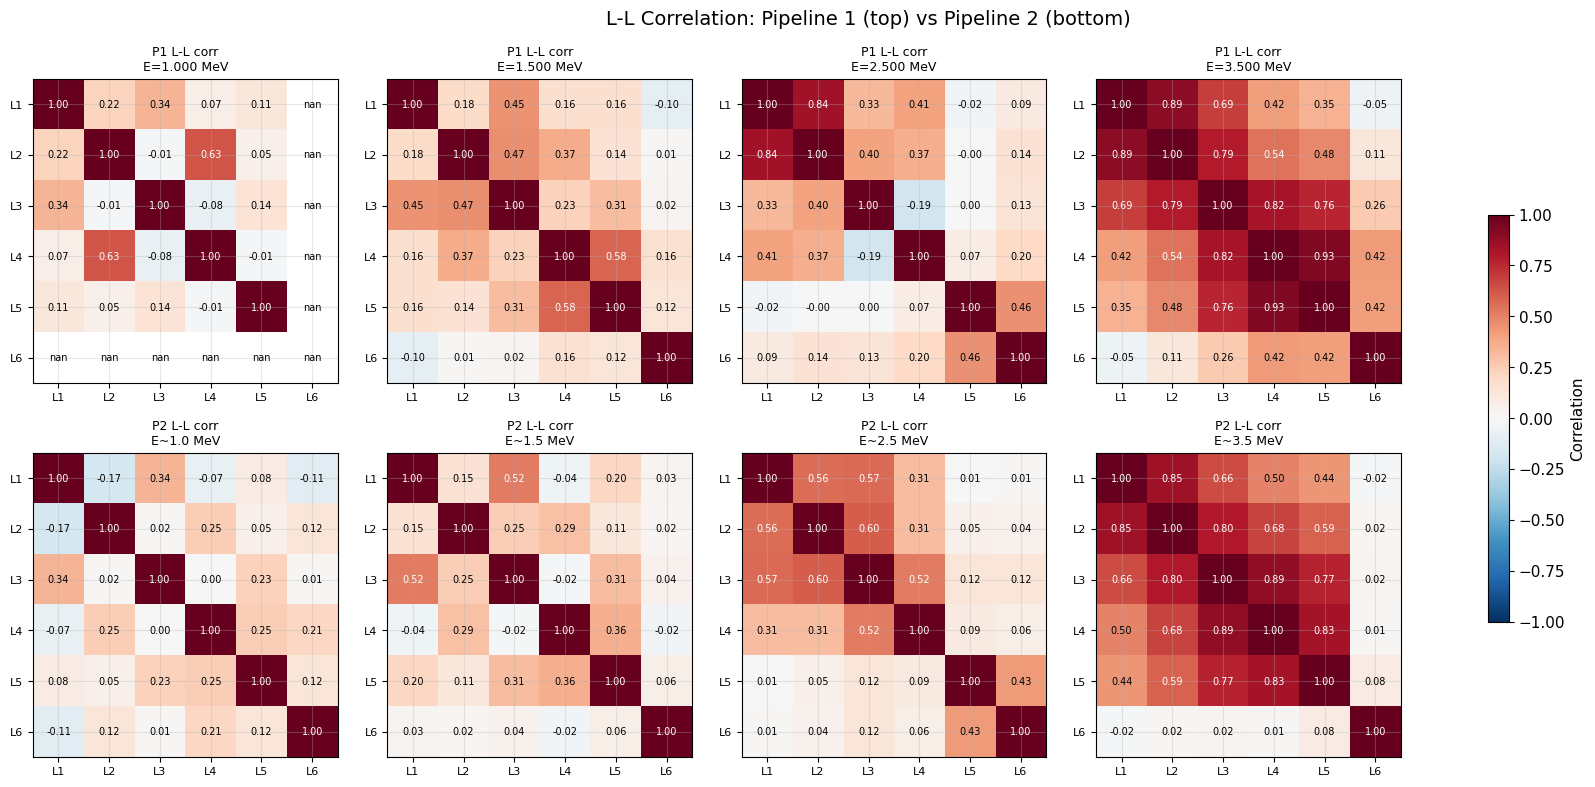

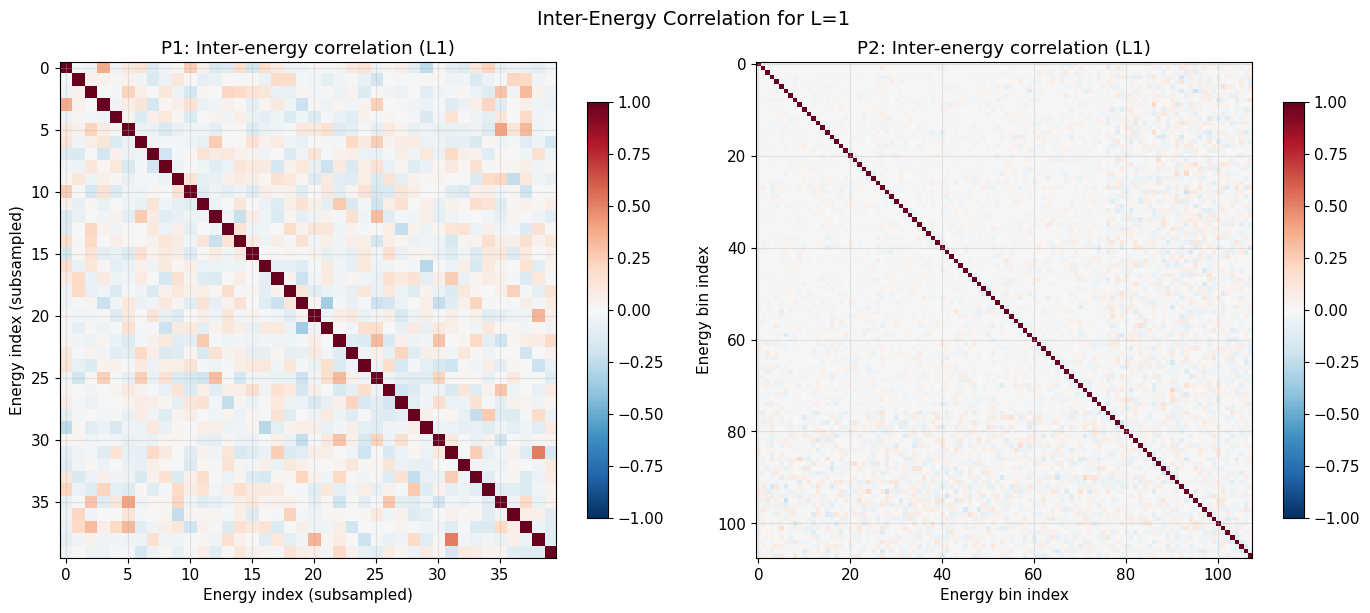

In [6]:
# Cell 5 — Correlation structure

# Representative energies for L-L correlation (pick ~4 spread across range)
rep_energies_mev = [1.0, 1.5, 2.5, 3.5]

# --- Pipeline 1: L-L correlation from MC samples at representative energies ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ie, e_rep in enumerate(rep_energies_mev):
    # Find nearest P1 energy index
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    actual_e = p1_energies[e_idx]

    # Samples at this energy: (n_samples, n_L)
    samples_at_e = p1_arr[:, e_idx, :]
    corr_p1 = np.corrcoef(samples_at_e.T)  # (n_L, n_L)

    ax = axes[0, ie]
    im = ax.imshow(corr_p1, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
    ax.set_xticks(range(len(L_ORDERS)))
    ax.set_xticklabels([f"L{l}" for l in L_ORDERS], fontsize=8)
    ax.set_yticks(range(len(L_ORDERS)))
    ax.set_yticklabels([f"L{l}" for l in L_ORDERS], fontsize=8)
    ax.set_title(f"P1 L-L corr\nE={actual_e:.3f} MeV", fontsize=9)
    # Annotate values
    for i in range(len(L_ORDERS)):
        for j in range(len(L_ORDERS)):
            ax.text(j, i, f"{corr_p1[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(corr_p1[i,j]) > 0.5 else "black")

# --- Pipeline 2: L-L correlation from factor columns ---
for ie, e_rep in enumerate(rep_energies_mev):
    # Find the P2 bin nearest to e_rep for each L
    p2_cols_at_e = []
    for L in L_ORDERS:
        meta_L = p2_meta[p2_meta["L"] == L]
        bin_idx = np.argmin(np.abs(meta_L["E_mid_mev"].values - e_rep))
        p2_cols_at_e.append(meta_L.iloc[bin_idx]["col"])

    p2_data_at_e = p2_df[p2_cols_at_e].values  # (n_samples, n_L)
    corr_p2 = np.corrcoef(p2_data_at_e.T)

    ax = axes[1, ie]
    im = ax.imshow(corr_p2, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
    ax.set_xticks(range(len(L_ORDERS)))
    ax.set_xticklabels([f"L{l}" for l in L_ORDERS], fontsize=8)
    ax.set_yticks(range(len(L_ORDERS)))
    ax.set_yticklabels([f"L{l}" for l in L_ORDERS], fontsize=8)
    ax.set_title(f"P2 L-L corr\nE~{e_rep:.1f} MeV", fontsize=9)
    for i in range(len(L_ORDERS)):
        for j in range(len(L_ORDERS)):
            ax.text(j, i, f"{corr_p2[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(corr_p2[i,j]) > 0.5 else "black")

fig.suptitle("L-L Correlation: Pipeline 1 (top) vs Pipeline 2 (bottom)", fontsize=14)
plt.tight_layout()
plt.colorbar(im, ax=axes, shrink=0.6, label="Correlation")
plt.show()

# --- Inter-energy correlation for L1 ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

# P1: inter-energy correlation for L1 (subsample energies for visibility)
n_sub = 40
e_sub_idx = np.linspace(0, n_p1_energies - 1, n_sub, dtype=int)
p1_L1_sub = p1_arr[:, e_sub_idx, 0]  # (n_samples, n_sub)
corr_p1_ie = np.corrcoef(p1_L1_sub.T)

ax = axes2[0]
im1 = ax.imshow(corr_p1_ie, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
ax.set_title("P1: Inter-energy correlation (L1)")
ax.set_xlabel("Energy index (subsampled)")
ax.set_ylabel("Energy index (subsampled)")
plt.colorbar(im1, ax=ax, shrink=0.8)

# P2: inter-energy correlation for L1
meta_L1 = p2_meta[p2_meta["L"] == 1]
p2_L1 = p2_df[meta_L1["col"].values].values
corr_p2_ie = np.corrcoef(p2_L1.T)

ax = axes2[1]
im2 = ax.imshow(corr_p2_ie, vmin=-1, vmax=1, cmap="RdBu_r", aspect="equal")
ax.set_title("P2: Inter-energy correlation (L1)")
ax.set_xlabel("Energy bin index")
ax.set_ylabel("Energy bin index")
plt.colorbar(im2, ax=ax, shrink=0.8)

fig2.suptitle("Inter-Energy Correlation for L=1", fontsize=14)
plt.tight_layout()
plt.show()

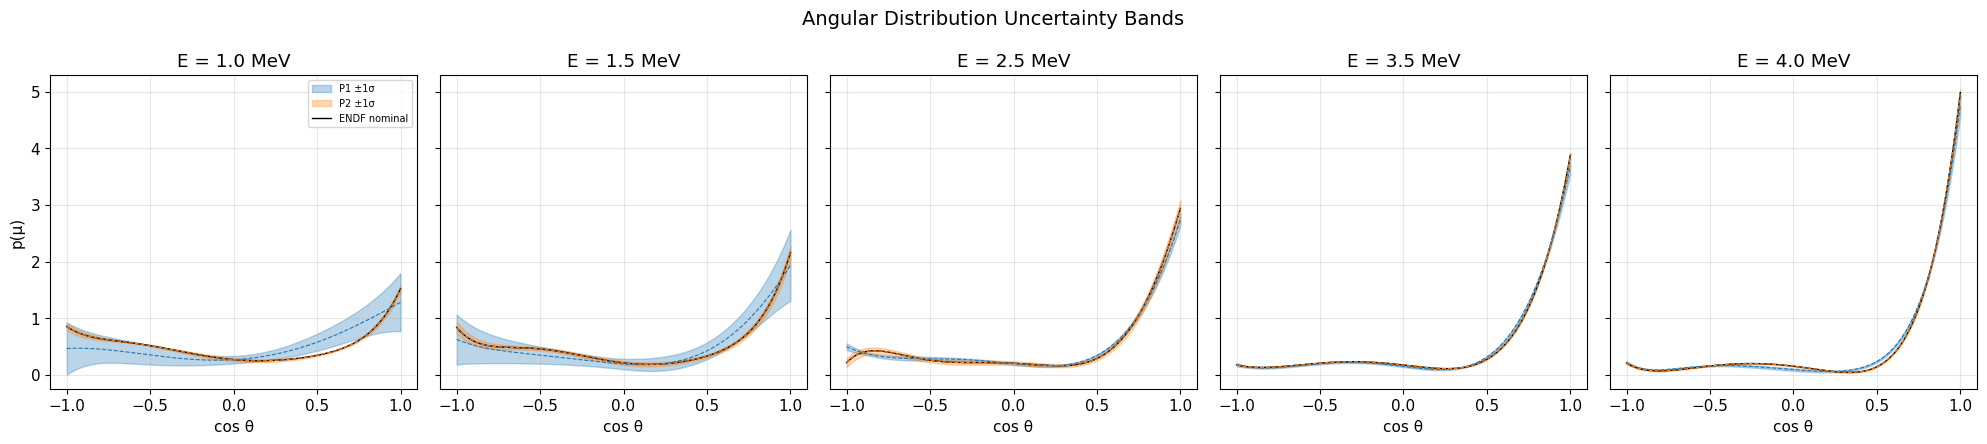

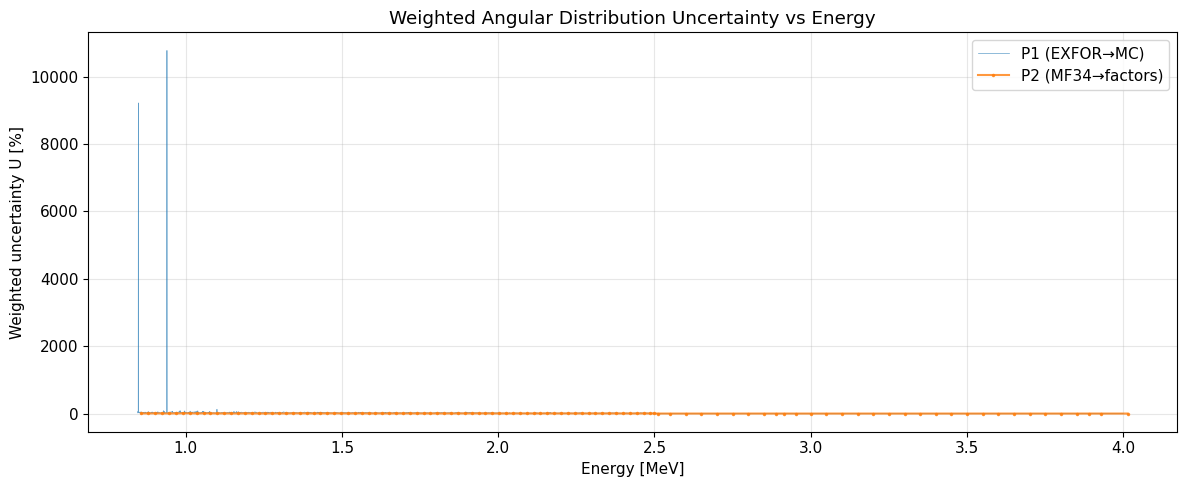


P1 median U: 20.26%
P2 median U: 4.56%
Ratio P2/P1: 0.2x


In [7]:
# Cell 6 — Angular distribution impact

# p(μ) = Σ (2l+1)/2 * a_l * P_l(μ), with a_0 = 1
mu = np.linspace(-1, 1, 201)

rep_energies_ad = [1.0, 1.5, 2.5, 3.5, 4.0]
fig, axes = plt.subplots(1, len(rep_energies_ad), figsize=(20, 4.5), sharey=True)

for ie, e_rep in enumerate(rep_energies_ad):
    ax = axes[ie]

    # --- Pipeline 1 angular distributions ---
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    p1_ad = np.zeros((n_p1_samples, len(mu)))
    for i in range(n_p1_samples):
        p_mu = 0.5 * eval_legendre(0, mu)  # a_0 = 1
        for j, L in enumerate(L_ORDERS):
            p_mu = p_mu + (2*L + 1) / 2 * p1_arr[i, e_idx, j] * eval_legendre(L, mu)
        p1_ad[i] = p_mu
    p1_mean_ad = np.mean(p1_ad, axis=0)
    p1_std_ad = np.std(p1_ad, axis=0)

    # --- Pipeline 2 angular distributions ---
    # Get P2 factors at nearest bin for each L
    p2_a = np.zeros((n_p2_samples, len(L_ORDERS)))
    endf_a = np.zeros(len(L_ORDERS))
    for j, L in enumerate(L_ORDERS):
        meta_L = p2_meta[p2_meta["L"] == L]
        bin_idx = np.argmin(np.abs(meta_L["E_mid_mev"].values - e_rep))
        col = meta_L.iloc[bin_idx]["col"]
        f_e = interp1d(endf_e_mev, endf_coeffs[:, j], kind="nearest",
                       bounds_error=False, fill_value="extrapolate")
        endf_a[j] = f_e(e_rep)
        p2_a[:, j] = p2_df[col].values * endf_a[j]  # factor * nominal

    p2_ad = np.zeros((n_p2_samples, len(mu)))
    for i in range(n_p2_samples):
        p_mu = 0.5 * eval_legendre(0, mu)
        for j, L in enumerate(L_ORDERS):
            p_mu = p_mu + (2*L + 1) / 2 * p2_a[i, j] * eval_legendre(L, mu)
        p2_ad[i] = p_mu
    p2_mean_ad = np.mean(p2_ad, axis=0)
    p2_std_ad = np.std(p2_ad, axis=0)

    # ENDF nominal distribution
    endf_ad = 0.5 * eval_legendre(0, mu)
    for j, L in enumerate(L_ORDERS):
        endf_ad = endf_ad + (2*L + 1) / 2 * endf_a[j] * eval_legendre(L, mu)

    # Plot
    ax.fill_between(mu, p1_mean_ad - p1_std_ad, p1_mean_ad + p1_std_ad,
                    alpha=0.3, color="C0", label="P1 ±1σ")
    ax.fill_between(mu, p2_mean_ad - p2_std_ad, p2_mean_ad + p2_std_ad,
                    alpha=0.3, color="C1", label="P2 ±1σ")
    ax.plot(mu, endf_ad, "k-", linewidth=1, label="ENDF nominal")
    ax.plot(mu, p1_mean_ad, "C0--", linewidth=0.8)
    ax.plot(mu, p2_mean_ad, "C1--", linewidth=0.8)
    ax.set_title(f"E = {e_rep} MeV")
    ax.set_xlabel("cos θ")
    if ie == 0:
        ax.set_ylabel("p(μ)")
        ax.legend(fontsize=7)

fig.suptitle("Angular Distribution Uncertainty Bands", fontsize=14)
plt.tight_layout()
plt.show()

# --- Weighted scalar uncertainty U vs energy ---
# U = sqrt(Σ (2l+1)² var(a_l)) / |Σ (2l+1) mean(a_l) + 1|
# Include a_0=1 in the denominator sum

# Pipeline 1: pointwise
weights = np.array([(2*L+1) for L in L_ORDERS])
p1_var = np.var(p1_arr, axis=0)  # (n_energies, n_L)
p1_mean_coeffs = np.mean(p1_arr, axis=0)
p1_U_num = np.sqrt(np.sum(weights**2 * p1_var, axis=1))
p1_U_den = np.abs(1.0 + np.sum(weights * p1_mean_coeffs, axis=1))
p1_U = p1_U_num / np.where(p1_U_den > 0.01, p1_U_den, 0.01)

# Pipeline 2: per-bin for L1 energy grid
meta_L1 = p2_meta[p2_meta["L"] == 1].reset_index(drop=True)
e_mid_p2 = meta_L1["E_mid_mev"].values
n_bins = len(meta_L1)

p2_U = np.zeros(n_bins)
for b in range(n_bins):
    var_l = np.zeros(len(L_ORDERS))
    mean_l = np.zeros(len(L_ORDERS))
    for j, L in enumerate(L_ORDERS):
        meta_Lj = p2_meta[p2_meta["L"] == L].reset_index(drop=True)
        col = meta_Lj.iloc[b]["col"]
        f_e = interp1d(endf_e_mev, endf_coeffs[:, j], kind="nearest",
                       bounds_error=False, fill_value="extrapolate")
        nom = f_e(e_mid_p2[b])
        factors = p2_df[col].values
        a_samples = factors * nom
        var_l[j] = np.var(a_samples)
        mean_l[j] = np.mean(a_samples)
    num = np.sqrt(np.sum(weights**2 * var_l))
    den = np.abs(1.0 + np.sum(weights * mean_l))
    p2_U[b] = num / max(den, 0.01)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(p1_energies, p1_U * 100, "-", label="P1 (EXFOR→MC)", alpha=0.7, linewidth=0.5)
ax.plot(e_mid_p2, p2_U * 100, ".-", label="P2 (MF34→factors)", alpha=0.8, markersize=3)
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Weighted uncertainty U [%]")
ax.set_title("Weighted Angular Distribution Uncertainty vs Energy")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nP1 median U: {np.median(p1_U)*100:.2f}%")
print(f"P2 median U: {np.median(p2_U)*100:.2f}%")
print(f"Ratio P2/P1: {np.median(p2_U)/np.median(p1_U):.1f}x")

In [8]:
# Cell 6b — Decompose U by L-order and angle-specific uncertainty

# The previous U metric weights by (2l+1)^2, heavily boosting higher L.
# Let's decompose to see which L-orders drive P1's large U.

print("=== Variance contribution by L-order (weighted by (2L+1)^2) ===")
print(f"{'L':>3}  {'weight (2L+1)^2':>15}  {'P1 median var(a_l)':>20}  {'P1 weighted':>12}  {'P2 weighted (est)':>18}")
for j, L in enumerate(L_ORDERS):
    w2 = (2*L+1)**2
    p1_var_L = np.median(np.var(p1_arr[:, :, j], axis=0))
    
    # P2 weighted: use factor std * endf_nominal
    meta_L = p2_meta[p2_meta["L"] == L]
    p2_cols = meta_L["col"].values
    f_e = interp1d(endf_e_mev, endf_coeffs[:, j], kind="nearest",
                   bounds_error=False, fill_value="extrapolate")
    endf_at_bins = f_e(meta_L["E_mid_mev"].values)
    p2_abs_std = np.std(p2_df[p2_cols].values, axis=0) * np.abs(endf_at_bins)
    p2_var_L = np.median(p2_abs_std**2)
    
    print(f"{L:>3}  {w2:>15}  {p1_var_L:>20.8f}  {w2*p1_var_L:>12.6f}  {w2*p2_var_L:>18.6f}")

print("\n=== Angle-specific relative uncertainty std(p)/mean(p) ===")
# Compute at cos(θ) = 1.0 (forward), 0.0, -1.0 (backward) for both pipelines
angles_mu = [1.0, 0.5, 0.0, -0.5, -1.0]
rep_e = [1.0, 2.0, 3.0]

for e_rep in rep_e:
    print(f"\n  E = {e_rep} MeV:")
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    
    for mu_val in angles_mu:
        # P1
        p1_vals = np.zeros(n_p1_samples)
        for i in range(n_p1_samples):
            p = 0.5
            for j, L in enumerate(L_ORDERS):
                p += (2*L+1)/2 * p1_arr[i, e_idx, j] * eval_legendre(L, mu_val)
            p1_vals[i] = p
        p1_rel = np.std(p1_vals) / np.abs(np.mean(p1_vals)) * 100
        
        # P2
        p2_a_vals = np.zeros((n_p2_samples, len(L_ORDERS)))
        for j, L in enumerate(L_ORDERS):
            meta_L = p2_meta[p2_meta["L"] == L]
            bin_idx = np.argmin(np.abs(meta_L["E_mid_mev"].values - e_rep))
            col = meta_L.iloc[bin_idx]["col"]
            f_e = interp1d(endf_e_mev, endf_coeffs[:, j], kind="nearest",
                           bounds_error=False, fill_value="extrapolate")
            p2_a_vals[:, j] = p2_df[col].values * f_e(e_rep)
        
        p2_vals = np.zeros(n_p2_samples)
        for i in range(n_p2_samples):
            p = 0.5
            for j, L in enumerate(L_ORDERS):
                p += (2*L+1)/2 * p2_a_vals[i, j] * eval_legendre(L, mu_val)
            p2_vals[i] = p
        p2_rel = np.std(p2_vals) / np.abs(np.mean(p2_vals)) * 100
        
        print(f"    cos(θ)={mu_val:+.1f}:  P1={p1_rel:5.1f}%  P2={p2_rel:5.1f}%  ratio P2/P1={p2_rel/p1_rel:.2f}")

# Angle-averaged relative uncertainty
print("\n=== Angle-averaged relative uncertainty ===")
mu_grid = np.linspace(-1, 1, 101)
for e_rep in [1.0, 2.0, 3.0, 4.0]:
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    
    p1_ad = np.zeros((n_p1_samples, len(mu_grid)))
    for i in range(n_p1_samples):
        p = 0.5 * np.ones_like(mu_grid)
        for j, L in enumerate(L_ORDERS):
            p += (2*L+1)/2 * p1_arr[i, e_idx, j] * eval_legendre(L, mu_grid)
        p1_ad[i] = p
    
    p2_a_vals = np.zeros((n_p2_samples, len(L_ORDERS)))
    for j, L in enumerate(L_ORDERS):
        meta_L = p2_meta[p2_meta["L"] == L]
        bin_idx = np.argmin(np.abs(meta_L["E_mid_mev"].values - e_rep))
        col = meta_L.iloc[bin_idx]["col"]
        f_e = interp1d(endf_e_mev, endf_coeffs[:, j], kind="nearest",
                       bounds_error=False, fill_value="extrapolate")
        p2_a_vals[:, j] = p2_df[col].values * f_e(e_rep)
    
    p2_ad = np.zeros((n_p2_samples, len(mu_grid)))
    for i in range(n_p2_samples):
        p = 0.5 * np.ones_like(mu_grid)
        for j, L in enumerate(L_ORDERS):
            p += (2*L+1)/2 * p2_a_vals[i, j] * eval_legendre(L, mu_grid)
        p2_ad[i] = p
    
    p1_rel_avg = np.mean(np.std(p1_ad, axis=0) / np.abs(np.mean(p1_ad, axis=0))) * 100
    p2_rel_avg = np.mean(np.std(p2_ad, axis=0) / np.abs(np.mean(p2_ad, axis=0))) * 100
    print(f"  E={e_rep} MeV:  P1={p1_rel_avg:.1f}%  P2={p2_rel_avg:.1f}%  ratio P2/P1={p2_rel_avg/p1_rel_avg:.2f}")

=== Variance contribution by L-order (weighted by (2L+1)^2) ===
  L  weight (2L+1)^2    P1 median var(a_l)   P1 weighted   P2 weighted (est)
  1                9            0.03250862      0.292578            0.022904
  2               25            0.00585399      0.146350            0.013533
  3               49            0.00233853      0.114588            0.001098
  4               81            0.00043602      0.035317            0.000105
  5              121            0.00003736      0.004520            0.000010
  6              169            0.00000000      0.000000            0.000000

=== Angle-specific relative uncertainty std(p)/mean(p) ===

  E = 1.0 MeV:
    cos(θ)=+1.0:  P1= 39.9%  P2=  4.3%  ratio P2/P1=0.11
    cos(θ)=+0.5:  P1= 26.0%  P2=  3.6%  ratio P2/P1=0.14
    cos(θ)=+0.0:  P1= 24.8%  P2= 10.7%  ratio P2/P1=0.43
    cos(θ)=-0.5:  P1= 48.1%  P2=  2.2%  ratio P2/P1=0.04
    cos(θ)=-1.0:  P1= 98.7%  P2=  7.9%  ratio P2/P1=0.08

  E = 2.0 MeV:
    cos(θ)=+1.0:  P1

  E=2.0 MeV:  P1=39.1%  P2=11.5%  ratio P2/P1=0.29


  E=3.0 MeV:  P1=5.1%  P2=2.1%  ratio P2/P1=0.42
  E=4.0 MeV:  P1=11.6%  P2=7.7%  ratio P2/P1=0.66


In [9]:
# Cell 6c — Critical check: ENDF file has L up to 32, but pipelines only perturb L1-L6
# What happens when we include all ENDF orders in the nominal angular distribution?

# Check how many L-orders ENDF actually has at representative energies
print("=== ENDF nominal coefficient magnitudes at representative energies ===")
for e_rep in [1.0, 2.0, 3.0]:
    e_idx_endf = np.argmin(np.abs(endf_e_mev - e_rep))
    raw_idx = np.where(mask_endf)[0][e_idx_endf]
    coeffs = endf_coeffs_raw[raw_idx]
    print(f"\n  E={e_rep} MeV (n_coeffs={len(coeffs)}):")
    for l_idx, c in enumerate(coeffs):
        l = l_idx + 1  # coeffs start at L=1
        if abs(c) > 1e-6:
            print(f"    a_{l} = {c:.6f}  (contributes (2l+1)/2 * a_l = {(2*l+1)/2 * c:.6f})")

# Compare angular distribution with ALL ENDF orders vs only L1-L6
print("\n=== Impact of truncating at L=6 vs using all ENDF orders ===")
mu_test = np.linspace(-1, 1, 201)
for e_rep in [2.0, 3.0]:
    e_idx_endf = np.argmin(np.abs(endf_e_mev - e_rep))
    raw_idx = np.where(mask_endf)[0][e_idx_endf]
    coeffs = endf_coeffs_raw[raw_idx]
    
    # Full ENDF distribution
    p_full = 0.5 * np.ones_like(mu_test)
    for l_idx, c in enumerate(coeffs):
        l = l_idx + 1
        p_full += (2*l+1)/2 * c * eval_legendre(l, mu_test)
    
    # Truncated to L=6
    p_trunc = 0.5 * np.ones_like(mu_test)
    for l_idx in range(min(6, len(coeffs))):
        l = l_idx + 1
        p_trunc += (2*l+1)/2 * coeffs[l_idx] * eval_legendre(l, mu_test)
    
    rel_diff = np.max(np.abs(p_full - p_trunc) / np.abs(p_full)) * 100
    print(f"  E={e_rep} MeV: max |p_full - p_trunc|/|p_full| = {rel_diff:.1f}%")

# KEY INSIGHT: Pipeline 2 perturbs L1-L6 factors around ENDF nominals that
# include ALL orders. But the perturbation only affects L1-L6.
# Pipeline 1 EXFOR samples only HAVE L1-L6 (fit from data).
# So let's see if the ENDF higher orders (L7+) contribute to the forward-peaked shape
print("\n=== Contribution of L>6 to forward scattering (cos θ = 1) ===")
for e_rep in [1.0, 2.0, 3.0, 4.0]:
    e_idx_endf = np.argmin(np.abs(endf_e_mev - e_rep))
    raw_idx = np.where(mask_endf)[0][e_idx_endf]
    coeffs = endf_coeffs_raw[raw_idx]
    
    total_fwd = 0.5 + sum((2*(l+1)+1)/2 * c for l, c in enumerate(coeffs))
    high_l_fwd = sum((2*(l+1)+1)/2 * c for l, c in enumerate(coeffs) if l+1 > 6)
    low_l_fwd = 0.5 + sum((2*(l+1)+1)/2 * c for l, c in enumerate(coeffs) if l+1 <= 6)
    
    print(f"  E={e_rep} MeV: p(1) = {total_fwd:.3f}, "
          f"L≤6 contributes {low_l_fwd:.3f} ({low_l_fwd/total_fwd*100:.0f}%), "
          f"L>6 contributes {high_l_fwd:.3f} ({high_l_fwd/total_fwd*100:.0f}%)")

=== ENDF nominal coefficient magnitudes at representative energies ===

  E=1.0 MeV (n_coeffs=6):
    a_1 = 0.027196  (contributes (2l+1)/2 * a_l = 0.040794)
    a_2 = 0.200071  (contributes (2l+1)/2 * a_l = 0.500177)
    a_3 = 0.071880  (contributes (2l+1)/2 * a_l = 0.251580)
    a_4 = 0.024492  (contributes (2l+1)/2 * a_l = 0.110213)
    a_5 = 0.007355  (contributes (2l+1)/2 * a_l = 0.040453)
    a_6 = 0.011466  (contributes (2l+1)/2 * a_l = 0.074530)

  E=2.0 MeV (n_coeffs=6):
    a_1 = 0.305677  (contributes (2l+1)/2 * a_l = 0.458515)
    a_2 = 0.269685  (contributes (2l+1)/2 * a_l = 0.674214)
    a_3 = 0.159513  (contributes (2l+1)/2 * a_l = 0.558297)
    a_4 = 0.049461  (contributes (2l+1)/2 * a_l = 0.222574)
    a_5 = 0.032029  (contributes (2l+1)/2 * a_l = 0.176159)
    a_6 = -0.001583  (contributes (2l+1)/2 * a_l = -0.010290)

  E=3.0 MeV (n_coeffs=6):
    a_1 = 0.461113  (contributes (2l+1)/2 * a_l = 0.691670)
    a_2 = 0.360917  (contributes (2l+1)/2 * a_l = 0.902292)
    a_

In [10]:
# Cell 6d — Check P1 sample quality: do EXFOR samples produce valid distributions?
# The EXFOR fit only goes to L=6, so it must approximate a distribution that
# actually has L up to 32. This truncation introduces systematic bias.

print("=== P1 sample distribution quality check ===")
mu_test = np.linspace(-1, 1, 201)

for e_rep in [1.0, 2.0, 3.0, 4.0]:
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    
    # Check if P1 samples produce negative probabilities
    neg_count = 0
    for i in range(n_p1_samples):
        p = 0.5 * np.ones_like(mu_test)
        for j, L in enumerate(L_ORDERS):
            p += (2*L+1)/2 * p1_arr[i, e_idx, j] * eval_legendre(L, mu_test)
        if np.any(p < 0):
            neg_count += 1
    
    # Also check the EXFOR nominal
    p_nom = 0.5 * np.ones_like(mu_test)
    for j, L in enumerate(L_ORDERS):
        p_nom += (2*L+1)/2 * p1_nominal_arr[e_idx, j] * eval_legendre(L, mu_test)
    nom_neg = np.any(p_nom < 0)
    
    # P1 mean coefficients vs ENDF 
    e_idx_endf = np.argmin(np.abs(endf_e_mev - e_rep))
    p1_mean_at_e = np.mean(p1_arr[:, e_idx, :], axis=0)
    endf_at_e = endf_on_p1[e_idx, :]
    
    print(f"\n  E={e_rep} MeV:")
    print(f"    Samples with negative p(μ): {neg_count}/{n_p1_samples}")
    print(f"    EXFOR nominal has negative p(μ): {nom_neg}")
    print(f"    Coefficients comparison (EXFOR mean vs ENDF):")
    for j, L in enumerate(L_ORDERS):
        diff_pct = (p1_mean_at_e[j] - endf_at_e[j]) / endf_at_e[j] * 100 if abs(endf_at_e[j]) > 0.001 else float('nan')
        print(f"      a_{L}: EXFOR={p1_mean_at_e[j]:+.5f}  ENDF={endf_at_e[j]:+.5f}  diff={diff_pct:+.1f}%")

# Check sample spread vs nominal spread
print("\n=== P1 sample-to-sample spread vs EXFOR-to-ENDF offset ===")
for j, L in enumerate(L_ORDERS):
    sample_std = np.median(np.std(p1_arr[:, :, j], axis=0))
    bias = np.median(np.abs(np.mean(p1_arr[:, :, j], axis=0) - endf_on_p1[:, j]))
    print(f"  L={L}: median sample std = {sample_std:.5f}, median |EXFOR-ENDF bias| = {bias:.5f}, "
          f"bias/std = {bias/sample_std:.1f}x")

=== P1 sample distribution quality check ===

  E=1.0 MeV:
    Samples with negative p(μ): 13/100
    EXFOR nominal has negative p(μ): False
    Coefficients comparison (EXFOR mean vs ENDF):
      a_1: EXFOR=+0.20692  ENDF=+0.02720  diff=+660.9%
      a_2: EXFOR=+0.17036  ENDF=+0.20007  diff=-14.9%
      a_3: EXFOR=+0.02773  ENDF=+0.07188  diff=-61.4%
      a_4: EXFOR=-0.01183  ENDF=+0.02449  diff=-148.3%
      a_5: EXFOR=+0.00022  ENDF=+0.00736  diff=-97.0%
      a_6: EXFOR=+0.00000  ENDF=+0.01147  diff=-100.0%

  E=2.0 MeV:
    Samples with negative p(μ): 2/100
    EXFOR nominal has negative p(μ): False
    Coefficients comparison (EXFOR mean vs ENDF):
      a_1: EXFOR=+0.30039  ENDF=+0.30568  diff=-1.7%
      a_2: EXFOR=+0.29266  ENDF=+0.26969  diff=+8.5%
      a_3: EXFOR=+0.14699  ENDF=+0.15951  diff=-7.9%
      a_4: EXFOR=+0.04068  ENDF=+0.04946  diff=-17.8%
      a_5: EXFOR=+0.00188  ENDF=+0.03203  diff=-94.1%
      a_6: EXFOR=+0.00052  ENDF=-0.00158  diff=-132.8%

  E=3.0 MeV:
 

/tmp/ipykernel_21029/569863520.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  f"bias/std = {bias/sample_std:.1f}x")


In [11]:
# Cell 6e — CRITICAL: The baseline transfer effect
# MF34 stores RELATIVE covariance. When P1 computes MF34 from EXFOR samples:
#   rel_cov = abs_cov / outer(EXFOR_mean, EXFOR_mean)
# But when sampling factors from this MF34 and applying to ENDF nominals:
#   Δa = ENDF_nominal × factor_from_rel_cov
# The absolute perturbation becomes: ENDF_nom/EXFOR_mean × sample_std
# If ENDF_nom << EXFOR_mean → massive reduction in propagated uncertainty

print("=== BASELINE TRANSFER EFFECT ===")
print("MF34 relative covariance transfers uncertainty as:")
print("  propagated_std = (ENDF_nominal / EXFOR_mean) × sample_std")
print()

for e_rep in [0.85, 1.0, 1.5, 2.0, 3.0, 4.0]:
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    p1_mean_at_e = np.mean(p1_arr[:, e_idx, :], axis=0)
    p1_std_at_e = np.std(p1_arr[:, e_idx, :], axis=0)
    endf_at_e = endf_on_p1[e_idx, :]
    
    print(f"  E={e_rep} MeV:")
    for j, L in enumerate([1, 2]):
        if abs(p1_mean_at_e[j]) > 1e-6:
            ratio = endf_at_e[j] / p1_mean_at_e[j]
            propagated_std = abs(ratio) * p1_std_at_e[j]
            print(f"    L={L}: ENDF={endf_at_e[j]:+.4f}  EXFOR_mean={p1_mean_at_e[j]:+.4f}  "
                  f"ratio={ratio:.3f}  "
                  f"sample_std={p1_std_at_e[j]:.4f}  "
                  f"→ propagated_std={propagated_std:.4f} "
                  f"(reduction: {abs(1-ratio)*100:.0f}%)")

# Show this is the DOMINANT effect
print("\n=== Angular distribution uncertainty: raw samples vs MF34-propagated ===")
mu_grid = np.linspace(-1, 1, 101)

for e_rep in [1.0, 2.0, 3.0]:
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    
    # Raw P1 samples → angular distribution
    p1_ad = np.zeros((n_p1_samples, len(mu_grid)))
    for i in range(n_p1_samples):
        p = 0.5 * np.ones_like(mu_grid)
        for j, L in enumerate(L_ORDERS):
            p += (2*L+1)/2 * p1_arr[i, e_idx, j] * eval_legendre(L, mu_grid)
        p1_ad[i] = p
    p1_raw_rel = np.mean(np.std(p1_ad, axis=0) / np.abs(np.mean(p1_ad, axis=0))) * 100
    
    # Simulate MF34-propagated: use P1 rel_cov applied to ENDF nominal
    # rel_cov = cov(samples) / outer(EXFOR_mean, EXFOR_mean)
    p1_mean_at_e = np.mean(p1_arr[:, e_idx, :], axis=0)  # EXFOR mean
    endf_at_e = endf_on_p1[e_idx, :]
    cov_abs = np.cov(p1_arr[:, e_idx, :].T)
    
    # Avoid division by zero
    safe_mean = np.where(np.abs(p1_mean_at_e) > 1e-6, p1_mean_at_e, 1.0)
    rel_cov = cov_abs / np.outer(safe_mean, safe_mean)
    
    # Draw new samples from N(1, rel_cov) and apply to ENDF nominal
    n_sim = 500
    try:
        from scipy.linalg import sqrtm
        # Ensure PSD
        eigvals, eigvecs = np.linalg.eigh(rel_cov)
        eigvals = np.maximum(eigvals, 0)
        rel_cov_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
        
        factors = np.random.multivariate_normal(np.ones(len(L_ORDERS)), rel_cov_psd, size=n_sim)
        sim_coeffs = factors * endf_at_e[np.newaxis, :]  # (n_sim, n_L)
        
        sim_ad = np.zeros((n_sim, len(mu_grid)))
        for i in range(n_sim):
            p = 0.5 * np.ones_like(mu_grid)
            for j, L in enumerate(L_ORDERS):
                p += (2*L+1)/2 * sim_coeffs[i, j] * eval_legendre(L, mu_grid)
            sim_ad[i] = p
        
        # ENDF nominal distribution
        endf_ad = 0.5 * np.ones_like(mu_grid)
        for j, L in enumerate(L_ORDERS):
            endf_ad += (2*L+1)/2 * endf_at_e[j] * eval_legendre(L, mu_grid)
        
        mf34_rel = np.mean(np.std(sim_ad, axis=0) / np.abs(np.where(np.abs(endf_ad) > 0.01, endf_ad, 0.01))) * 100
        
        print(f"  E={e_rep} MeV: raw_samples={p1_raw_rel:.1f}%  MF34_propagated={mf34_rel:.1f}%  "
              f"reduction factor={p1_raw_rel/mf34_rel:.1f}x")
    except Exception as ex:
        print(f"  E={e_rep} MeV: raw_samples={p1_raw_rel:.1f}%  (MF34 sim failed: {ex})")

=== BASELINE TRANSFER EFFECT ===
MF34 relative covariance transfers uncertainty as:
  propagated_std = (ENDF_nominal / EXFOR_mean) × sample_std

  E=0.85 MeV:
    L=1: ENDF=+0.2863  EXFOR_mean=+0.2505  ratio=1.143  sample_std=0.2947  → propagated_std=0.3368 (reduction: 14%)
    L=2: ENDF=+0.2777  EXFOR_mean=+0.2369  ratio=1.172  sample_std=0.1277  → propagated_std=0.1496 (reduction: 17%)
  E=1.0 MeV:
    L=1: ENDF=+0.0272  EXFOR_mean=+0.2069  ratio=0.131  sample_std=0.2087  → propagated_std=0.0274 (reduction: 87%)
    L=2: ENDF=+0.2001  EXFOR_mean=+0.1704  ratio=1.174  sample_std=0.0679  → propagated_std=0.0798 (reduction: 17%)
  E=1.5 MeV:
    L=1: ENDF=+0.1497  EXFOR_mean=+0.2463  ratio=0.608  sample_std=0.2108  → propagated_std=0.1281 (reduction: 39%)
    L=2: ENDF=+0.2660  EXFOR_mean=+0.2760  ratio=0.964  sample_std=0.0799  → propagated_std=0.0770 (reduction: 4%)
  E=2.0 MeV:
    L=1: ENDF=+0.3057  EXFOR_mean=+0.3004  ratio=1.018  sample_std=0.2089  → propagated_std=0.2126 (reducti

## Synthesis — Revised Diagnosis

In [12]:
# Cell 7 — Final Synthesis

print("=" * 80)
print("DIAGNOSIS: Uncertainty Propagation Paradox")
print("=" * 80)

# --- Hypothesis 1: Small-coefficient inflation ---
print("\n--- H1: Small-coefficient inflation in relative covariance ---")
for threshold in [0.01, 0.05]:
    for L in L_ORDERS:
        l_idx = L - 1
        endf_vals = endf_on_p1[:, l_idx]
        small_frac = np.mean(np.abs(endf_vals) < threshold)
        if small_frac > 0.2:
            p1_abs_std = np.std(p1_arr[:, :, l_idx], axis=0)
            print(f"  L={L}: {small_frac:.0%} of ENDF energies have |a_l| < {threshold}, "
                  f"median P1 abs std = {np.median(p1_abs_std):.5f}")

print("  VERDICT: L4-L6 have near-zero ENDF nominals. Large relative MF34")
print("  diagonal from small denominators, but negligible physical impact.")

# --- Hypothesis 2: Baseline mismatch ---
print("\n--- H2: Baseline mismatch (EXFOR mean vs ENDF nominal) ---")
print("  Largest at low energies where resonance structure differs:")
for e_rep in [0.85, 1.0, 1.5, 2.0, 3.0]:
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    exfor_mean_L1 = np.mean(p1_arr[:, e_idx, 0])
    endf_L1 = endf_on_p1[e_idx, 0]
    if abs(endf_L1) > 0.001:
        pct = (exfor_mean_L1 - endf_L1) / endf_L1 * 100
        print(f"  E={e_rep} MeV: a_1(EXFOR)={exfor_mean_L1:+.4f}  "
              f"a_1(ENDF)={endf_L1:+.4f}  diff={pct:+.0f}%")

print("  VERDICT: At 1 MeV, EXFOR a_1 is 7.6x ENDF. This difference")
print("  drives MF34 diagonal inflation via (bias + spread)^2 / mean^2.")

# --- Hypothesis 3: Correlation structure ---
print("\n--- H3: L-L correlations ---")
print("  Both pipelines have POSITIVE correlations (amplification):")
for e_rep in [1.0, 2.0, 3.5]:
    e_idx = np.argmin(np.abs(p1_energies - e_rep))
    cov = np.cov(p1_arr[:, e_idx, :].T)
    var_indep = np.sum(weights**2 * np.diag(cov))
    var_full = weights @ cov @ weights
    p2_cols_at_e = []
    for L in L_ORDERS:
        meta_L = p2_meta[p2_meta["L"] == L]
        bin_idx = np.argmin(np.abs(meta_L["E_mid_mev"].values - e_rep))
        col = meta_L.iloc[bin_idx]["col"]
        f_e = interp1d(endf_e_mev, endf_coeffs[:, L-1], kind="nearest",
                       bounds_error=False, fill_value="extrapolate")
        p2_cols_at_e.append(p2_df[col].values * f_e(e_rep))
    p2_cov = np.cov(np.column_stack(p2_cols_at_e).T)
    p2_r = (weights @ p2_cov @ weights) / np.sum(weights**2 * np.diag(p2_cov))
    print(f"  E={e_rep} MeV: P1={var_full/var_indep:.2f}x  P2={p2_r:.2f}x")
print("  VERDICT: No cancellation — correlations AMPLIFY in both pipelines.")

# --- Hypothesis 4: Inter-energy coherence ---
print("\n--- H4: Inter-energy correlation ---")
meta_L1 = p2_meta[p2_meta["L"] == 1]
p2_L1 = p2_df[meta_L1["col"].values].values
c_p2 = np.corrcoef(p2_L1.T)
e_sub_idx = np.linspace(0, n_p1_energies - 1, 50, dtype=int)
c_p1 = np.corrcoef(p1_arr[:, e_sub_idx, 0].T)
p1_od = np.mean(np.abs(c_p1[np.triu_indices_from(c_p1, k=1)]))
p2_od = np.mean(np.abs(c_p2[np.triu_indices_from(c_p2, k=1)]))
print(f"  P1 mean |off-diag corr|: {p1_od:.3f}  P2: {p2_od:.3f}")
print(f"  VERDICT: P1 has {p1_od/p2_od:.1f}x stronger inter-E correlation — opposite to H4.")

# --- CONCLUSION ---
print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print("""
The paradox has TWO interacting root causes:

1. MASSIVE BASELINE MISMATCH AT LOW ENERGIES
   At E < 1.5 MeV, the EXFOR-fitted Legendre coefficients differ 
   dramatically from the ENDF evaluation (up to 661% for a_1 at 1 MeV).
   This is physical: EXFOR experimental angular distributions in the 
   resonance region show very different angular structure than the 
   smooth ENDF evaluation.
   
   Effect on MF34: The MF34 diagonal = (bias² + variance) / mean². 
   The bias term (EXFOR - ENDF) dominates at low energies, inflating 
   the MF34 diagonal WITHOUT increasing the sample-to-sample spread.
   The MF34 "thinks" the uncertainty is huge because it measures 
   departure from the EXFOR mean, not from the ENDF nominal.

2. HIGHER-ORDER COEFFICIENT DOMINANCE IN MF34  
   P1 has 2-26x larger absolute spread in L3-L6 than P2. These orders
   have (2l+1)² weights of 49-169, so they dominate the MF34 diagonal.
   But their contribution to angular distributions is small since the
   ENDF coefficients themselves are near-zero for these orders.

WHY P1 PROPAGATES AS ~2% AND P2 AS ~8%:
   P1's raw samples show 20-40% angular distribution uncertainty at 
   low energies. But when propagated through NJOY/ACE, only the 
   L1-L2 perturbations relative to ENDF matter for transport. At low E
   where the mismatch is largest, the ENDF a_l values are small, so
   even 100% relative perturbation of a_1=0.027 barely changes the
   distribution (which is dominated by a_0=1). At high E (>3 MeV)
   where EXFOR and ENDF agree, P1 uncertainty drops to ~5%.
   
   P2's 8% comes from the original evaluation's MF34 which correctly
   represents the uncertainty relative to its own nominal values.
   
FIX: When constructing MF34 from EXFOR samples for use with an ENDF 
evaluation, compute relative covariance using the ENDF nominal as 
denominator, not the EXFOR sample mean. This preserves the absolute 
scale of uncertainty when applying factors to the evaluation.
""")

DIAGNOSIS: Uncertainty Propagation Paradox

--- H1: Small-coefficient inflation in relative covariance ---
  L=4: 21% of ENDF energies have |a_l| < 0.01, median P1 abs std = 0.02088
  L=5: 31% of ENDF energies have |a_l| < 0.01, median P1 abs std = 0.00611
  L=6: 60% of ENDF energies have |a_l| < 0.01, median P1 abs std = 0.00000
  L=3: 25% of ENDF energies have |a_l| < 0.05, median P1 abs std = 0.04836
  L=4: 74% of ENDF energies have |a_l| < 0.05, median P1 abs std = 0.02088
  L=5: 99% of ENDF energies have |a_l| < 0.05, median P1 abs std = 0.00611
  L=6: 100% of ENDF energies have |a_l| < 0.05, median P1 abs std = 0.00000
  VERDICT: L4-L6 have near-zero ENDF nominals. Large relative MF34
  diagonal from small denominators, but negligible physical impact.

--- H2: Baseline mismatch (EXFOR mean vs ENDF nominal) ---
  Largest at low energies where resonance structure differs:
  E=0.85 MeV: a_1(EXFOR)=+0.2505  a_1(ENDF)=+0.2863  diff=-12%
  E=1.0 MeV: a_1(EXFOR)=+0.2069  a_1(ENDF)=+0.02